<img style="float:left" width="70%" src="pics/escudo_COLOR_1L_DCHA.png">
<img style="float:right" width="15%" src="pics/PythonLogo.svg">
<br style="clear:both;">

<h2 style="display: inline-block; padding: 4mm; padding-left: 2em; background-color: navy; line-height: 1.3em; color: white; border-radius: 10px;">Contornos activos para segmentación.</h2>

### Contornos activos y *Morphological Snakes*
#### Author: Pedro Latorre Carmona

### Alumno: Pablo Fernández Gumiel

##### Curso 2025-2026

Versión 1.0

---

# 1 Configuración del Entorno y Librerías

En esta celda importamos las herramientas necesarias para el procesamiento de imágenes y cálculo numérico:

* **`numpy`**: Esencial para manejar las imágenes como matrices numéricas (arrays).
* **`matplotlib.pyplot`**: Se utiliza para visualizar los resultados (imágenes originales vs. segmentadas).
* **`scikit-image (skimage)`**: La librería principal de la práctica. De aquí extraemos:
    * `filters`: Para aplicar filtros gaussianos (suavizado), cruciales para el funcionamiento de los *Snakes*.
    * `segmentation.active_contour`: La implementación del algoritmo de **Contornos Activos (Snakes)**.
    * `draw.polygon2mask`: Para convertir el contorno vectorial resultante en una máscara binaria evaluable.
* **`sklearn.metrics`**: Nos permite calcular métricas estadísticas (precisión, sensibilidad) para validar nuestros resultados.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, img_as_float
from skimage.filters import gaussian
from skimage.segmentation import active_contour
from scipy import ndimage as ndi
from itertools import cycle
from sklearn.metrics import confusion_matrix
from skimage.draw import polygon2mask

# 2 Definición de Funciones de Evaluación para contornos activos

El algoritmo `active_contour` devuelve una lista de coordenadas $(x, y)$ que forman el borde del objeto. Sin embargo, para saber qué tan buena es la segmentación, necesitamos comparar áreas, no solo bordes. Para ello definimos dos funciones:

### 1. `snake_to_mask`
Convierte el resultado vectorial del Snake en una **máscara binaria** (imagen en blanco y negro).
* **Entrada**: Coordenadas del contorno.
* **Salida**: Una matriz booleana donde `True` (o 1) representa el interior del objeto y `False` (o 0) el fondo. Esto nos permite comparar píxel a píxel con la solución real ("Ground Truth").

### 2. `calculate_metrics`

En segmentación de imágenes, la inspección visual ("parece que el contorno está bien") es subjetiva. Para evaluar científicamente el rendimiento de los *Active Contours*, comparamos el resultado obtenido (predicción) contra una **Máscara de Referencia** o *Ground Truth* (la solución ideal marcada por un experto).

Esta comparación se realiza píxel a píxel, clasificando cada punto de la imagen en una de cuatro categorías (Matriz de Confusión):

* **Verdadero Positivo (TP):** Píxeles que son objeto y detectamos correctamente como objeto.
* **Verdadero Negativo (TN):** Píxeles que son fondo y detectamos correctamente como fondo.
* **Falso Positivo (FP):** Píxeles de fondo que incorrectamente marcamos como objeto (el contorno se "desbordó").
* **Falso Negativo (FN):** Píxeles de objeto que incorrectamente marcamos como fondo (el contorno se quedó corto).

A partir de estos conteos, derivamos las tres métricas fundamentales de esta práctica:

### 1. Sensibilidad (Recall o Tasa de Verdaderos Positivos)
$$Sensibilidad = \frac{TP}{TP + FN}$$

* **¿Qué mide?** La **"Cobertura"**. Responde a la pregunta: *De todo el objeto que existe en la realidad, ¿cuánto fui capaz de encontrar?*
* **Interpretación:**
    * **Valor Ideal (1.0):** Hemos detectado el objeto en su totalidad.
    * **Valor Bajo (< 0.8):** **Sub-segmentación**. Nos hemos dejado partes importantes del objeto fuera del contorno (ej. la serpiente no entró en los brazos de la estrella).
* **Comportamiento en Snakes:** Aumenta cuando permitimos que la serpiente se expanda o se adapte a concavidades (Beta bajo). Disminuye si la tensión (Alpha) es excesiva y la serpiente se contrae demasiado.

### 2. Especificidad (Tasa de Verdaderos Negativos)
$$Especificidad = \frac{TN}{TN + FP}$$

* **¿Qué mide?** La capacidad de **"Rechazo"**. Responde a la pregunta: *De todo el fondo que existe, ¿cuánto fui capaz de ignorar correctamente?*
* **Interpretación:**
    * **Valor Ideal (1.0):** No hemos seleccionado nada que no sea objeto.
    * **Nota:** En segmentación de objetos pequeños sobre fondos grandes, este valor suele ser muy alto (cercano a 0.99) incluso en malas segmentaciones, porque la gran mayoría de la imagen es fondo (TN). Por eso, no es la métrica más sensible para detectar errores finos.

### 3. Precisión (Precision o Valor Predictivo Positivo)
$$Precisión = \frac{TP}{TP + FP}$$

* **¿Qué mide?** La **"Fiabilidad"** o **"Pureza"**. Responde a la pregunta: *De todo lo que yo dije que era objeto, ¿cuánto es realmente objeto?*
* **Interpretación:**
    * **Valor Ideal (1.0):** Todo lo que está dentro de mi contorno es parte del objeto real.
    * **Valor Bajo:** **Sobre-segmentación**. Hemos incluido "basura", ruido o fondo dentro de nuestra selección.
* **Comportamiento en Snakes:** Cae drásticamente si la serpiente se "fuga" hacia el fondo o si captura ruido interno (como en la ecografía) que no debería ser parte de la selección.

### ¿Por qué necesitamos las tres? (El equilibrio)

Ninguna métrica por sí sola cuenta la historia completa:
1.  Si seleccionamos la **imagen entera** como objeto, tendríamos **Sensibilidad = 1.0** (excelente), pero una **Precisión** terrible (pésima), porque hemos capturado todo el fondo.
2.  Si seleccionamos **un solo píxel** correcto del objeto, tendríamos **Precisión = 1.0** (excelente), pero una **Sensibilidad** cercana a 0 (pésima), porque nos falta casi todo el objeto.

**El objetivo de la práctica** es encontrar la configuración de `alpha` y `beta` que maximice tanto la Sensibilidad como la Precisión simultáneamente, indicando un ajuste perfecto al contorno real.

In [ ]:
# Funciones Auxiliares para Active Contours

def snake_to_mask(snake, img_shape):
    """Convierte el contorno del snake (puntos) a una máscara binaria."""
    mask = polygon2mask(img_shape, snake)
    return mask

def calculate_metrics(ground_truth, prediction):
    """Calcula Sensibilidad, Especificidad y Precisión."""
    # Asegurar booleanos
    gt = ground_truth.astype(bool)
    pred = prediction.astype(bool)
    
    TP = np.sum(gt & pred)
    TN = np.sum(~gt & ~pred)
    FP = np.sum(~gt & pred)
    FN = np.sum(gt & ~pred)
    
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    
    return sensitivity, specificity, precision

# 3 Experimentación: Ajuste de Alpha y Beta en Contornos Activos

En esta sección realizamos un **Grid Search** (búsqueda en rejilla) para encontrar la configuración óptima del algoritmo.

### Fundamento Matemático
Los *Snakes* buscan minimizar una función de energía $E$ definida como:
$$E = \int ( E_{interna}(v(s)) + E_{externa}(v(s)) ) ds$$

La **Energía Interna** controla la forma de la serpiente y depende de dos parámetros clave que vamos a variar:

1.  **ALPHA ($\alpha$) - Continuidad / Tensión (Elasticidad):**
    * Multiplica a la primera derivada del contorno.
    * Actúa como la tensión de una goma elástica.
    * **$\alpha$ alto**: La serpiente tiende a contraerse rápidamente y mantenerse recta entre puntos.
    * **$\alpha$ bajo**: La serpiente es más "laxa" y puede estirarse para cubrir perímetros largos.

2.  **BETA ($\beta$) - Suavidad / Rigidez (Curvatura):**
    * Multiplica a la segunda derivada del contorno.
    * Actúa como la resistencia a doblarse (como un alambre vs. una cuerda).
    * **$\beta$ alto**: Penaliza las curvas cerradas. Obliga al contorno a ser suave (circular/elíptico).
    * **$\beta$ bajo**: Permite esquinas afiladas y cambios bruscos de dirección para adaptarse a detalles finos.


## Caso de Estudio: Segmentación de una Estrella de Mar

En este primer ejemplo aplicaremos el algoritmo a una forma geométrica compleja: una estrella de mar.
* **Imagen**: `seastar2.png` (escala de grises).
* **Referencia**: `Mascara_estrella.png`.

### El Reto: Concavidades
Las estrellas tienen una topología desafiante para los *Snakes* clásicos: las **concavidades** profundas entre los brazos.
La "fuerza elástica" (Alpha) tiende a acortar la serpiente, haciendo que esta prefiera quedarse recta entre las puntas de los brazos en lugar de entrar en los huecos (como si pusiéramos una goma elástica alrededor de una estrella real).

**Objetivo del Experimento:**
Observar si disminuyendo la rigidez (**Beta**) y la tensión (**Alpha**), la serpiente logra "relajarse" lo suficiente para entrar en los huecos entre los brazos y capturar la forma completa.

Ejecutando análisis combinado (Visualización + Métricas)...


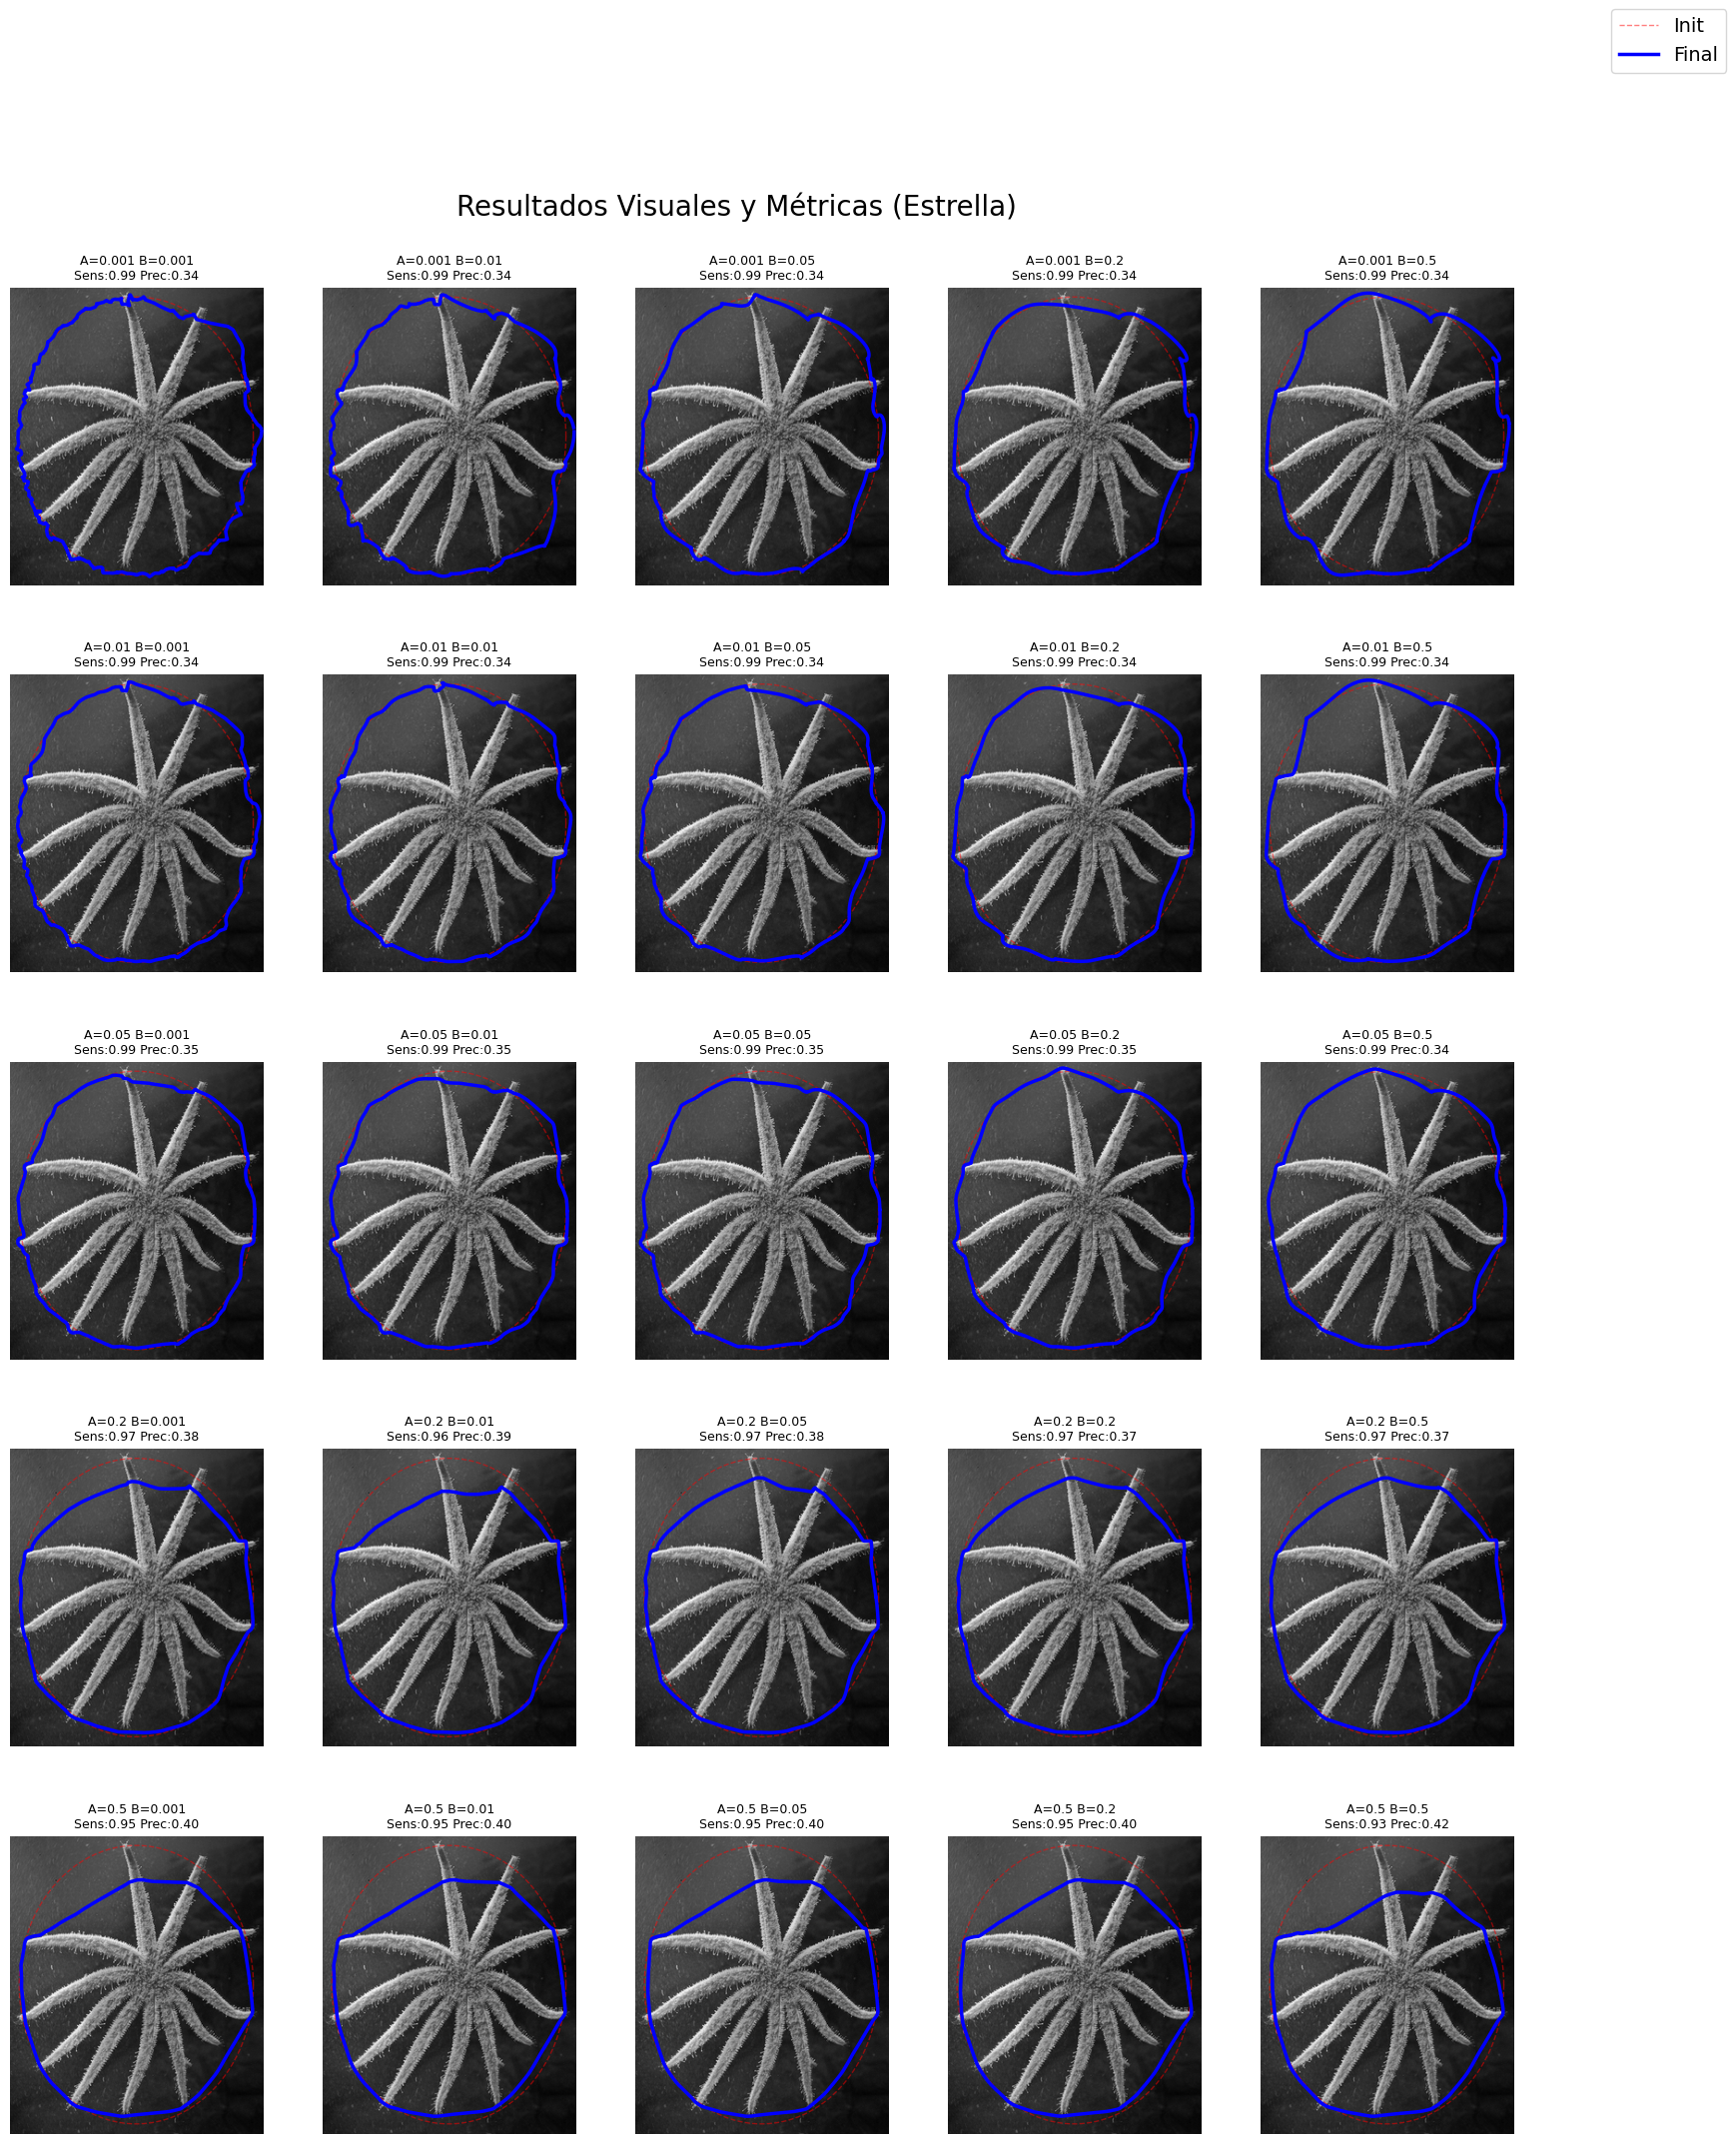


                  TABLA DE RESULTADOS NUMÉRICOS                  
  Alpha    |    Beta    |  Sensib.   |  Especif.  |  Precis.  
-----------------------------------------------------------------
  0.001    |   0.001    |   0.986    |   0.403    |   0.338   
  0.001    |   0.010    |   0.988    |   0.399    |   0.337   
  0.001    |   0.050    |   0.991    |   0.411    |   0.342   
  0.001    |   0.200    |   0.988    |   0.414    |   0.343   
  0.001    |   0.500    |   0.993    |   0.407    |   0.341   
  0.010    |   0.001    |   0.988    |   0.407    |   0.340   
  0.010    |   0.010    |   0.987    |   0.411    |   0.342   
  0.010    |   0.050    |   0.988    |   0.416    |   0.344   
  0.010    |   0.200    |   0.987    |   0.418    |   0.344   
  0.010    |   0.500    |   0.992    |   0.411    |   0.343   
  0.050    |   0.001    |   0.987    |   0.421    |   0.345   
  0.050    |   0.010    |   0.986    |   0.423    |   0.346   
  0.050    |   0.050    |   0.986    |   0.428  

In [ ]:
# Cargar imagen original
img_path = 'images/seastar2.png'
img = io.imread(img_path)
if len(img.shape) > 2: img = color.rgb2gray(img)
img = img_as_float(img)
img_smooth = gaussian(img, 1) # Suavizado ligero para el algoritmo
rows, cols = img.shape

# Cargar Ground Truth (La máscara ideal)
mask_star_gt = io.imread('images/Mascara_estrella.png', as_gray=True) > 0.5

# Inicialización del Snake (Círculo grande)
s = np.linspace(0, 2*np.pi, 600)
r = rows//2 + (rows//2 - 10)*np.sin(s)
c = cols//2 + (cols//2 - 10)*np.cos(s)
init = np.array([r, c]).T

# --- 3. CONFIGURACIÓN DE PARÁMETROS ---
alphas = [0.001, 0.01, 0.05, 0.2, 0.5] # Tensión
betas = [0.001, 0.01, 0.05, 0.2, 0.5]  # Rigidez

# Preparar figura y lista para guardar resultados
fig, axes = plt.subplots(5, 5, figsize=(20, 24), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.05, hspace=0.3)
metric_results = [] # Aquí guardaremos los datos para la tabla

print("Ejecutando análisis combinado (Visualización + Métricas)...")

# --- 4. BUCLE PRINCIPAL (GRID SEARCH) ---
for i, alpha in enumerate(alphas):
    for j, beta in enumerate(betas):
        ax = axes[i, j]
        
        # A. Ejecutar Active Contour (Parámetros del código visual)
        snake = active_contour(img_smooth, init, alpha=alpha, beta=beta, 
                               w_line=-2.0, w_edge=2.0, gamma=0.01, max_num_iter=2500)
        
        # B. Calcular Métricas
        mask_pred = snake_to_mask(snake, img.shape)
        sens, spec, prec = calculate_metrics(mask_star_gt, mask_pred)
        
        # Guardar dato para tabla final
        metric_results.append((alpha, beta, sens, spec, prec))
        
        # C. Visualización
        ax.imshow(img, cmap='gray')
        ax.plot(init[:, 1], init[:, 0], '--r', lw=1.0, alpha=0.5, label='Init')
        ax.plot(snake[:, 1], snake[:, 0], '-b', lw=2.5, label='Final')
        
        ax.set_xlim(0, cols)
        ax.set_ylim(rows, 0)
        
        # Título con métricas clave para referencia rápida visual
        ax.set_title(f"A={alpha} B={beta}\nSens:{sens:.2f} Prec:{prec:.2f}", fontsize=9)
        ax.axis('off')

# Añadir leyenda y título global
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=14)
plt.suptitle("Resultados Visuales y Métricas", y=0.92, fontsize=20)
plt.show()

# --- 5. IMPRIMIR TABLA DE RESULTADOS ---
print("\n" + "="*65)
print(f"{'TABLA DE RESULTADOS NUMÉRICOS':^65}")
print("="*65)
print(f"{'Alpha':^10} | {'Beta':^10} | {'Sensib.':^10} | {'Especif.':^10} | {'Precis.':^10}")
print("-" * 65)

for res in metric_results:
    print(f"{res[0]:^10.3f} | {res[1]:^10.3f} | {res[2]:^10.3f} | {res[3]:^10.3f} | {res[4]:^10.3f}")
print("="*65)

### Análisis de Resultados: Estrella de Mar

Al observar la matriz de resultados gráficas y la tabla, deberíamos notar lo siguiente:

1.  **Efecto "Dedos Palmeados" (Beta Alto)**:
    * En las columnas de la derecha (Beta alto, ej. > 0.1), la serpiente es demasiado rígida. Une las puntas de los brazos con curvas suaves, fallando en capturar las concavidades. Esto reduce la **Sensibilidad** y la **Precisión** en esas zonas.

2.  **Ajuste Óptimo (Beta y Alpha Bajos)**:
    * Para capturar los picos de la estrella y los valles profundos, necesitamos valores bajos (ej. Alpha=0.01, Beta=0.001). Esto permite que la curva se doble bruscamente en las puntas y se estire hacia adentro entre los brazos.

3.  **Colapso (Alpha muy Alto)**:
    * Si Alpha es muy alto, la serpiente podría encogerse demasiado y quedarse en el centro de la estrella, perdiendo los brazos por completo.

Lo que vemos en las Métricas es que la sensibilidad es muy alta porque coge todo el objeto en la mayor parte de los casos pero la precisión y la especificidad nos dice en todos los casos que los resultados no son buenos.

## Caso de Estudioç: Segmentación de Lagos

Aquí trabajamos con una imagen de satélite/aérea de un entorno natural.
* **Imagen**: `lakes3.jpg`.
* **Referencia**: `Mascara_lagos.png`.

### El Reto: Bordes Irregulares y Textura
A diferencia de la estrella (que es un objeto sólido sobre fondo liso), los lagos tienen:
1.  **Bordes cortantes**: La costa es muy rugosa, no es una línea perfecta.
2.  **Contraste variable**: Algunas orillas pueden tener arena clara (buen contraste) y otras vegetación oscura (bajo contraste con el agua).

Ejecutando análisis combinado (Visualización + Métricas)...


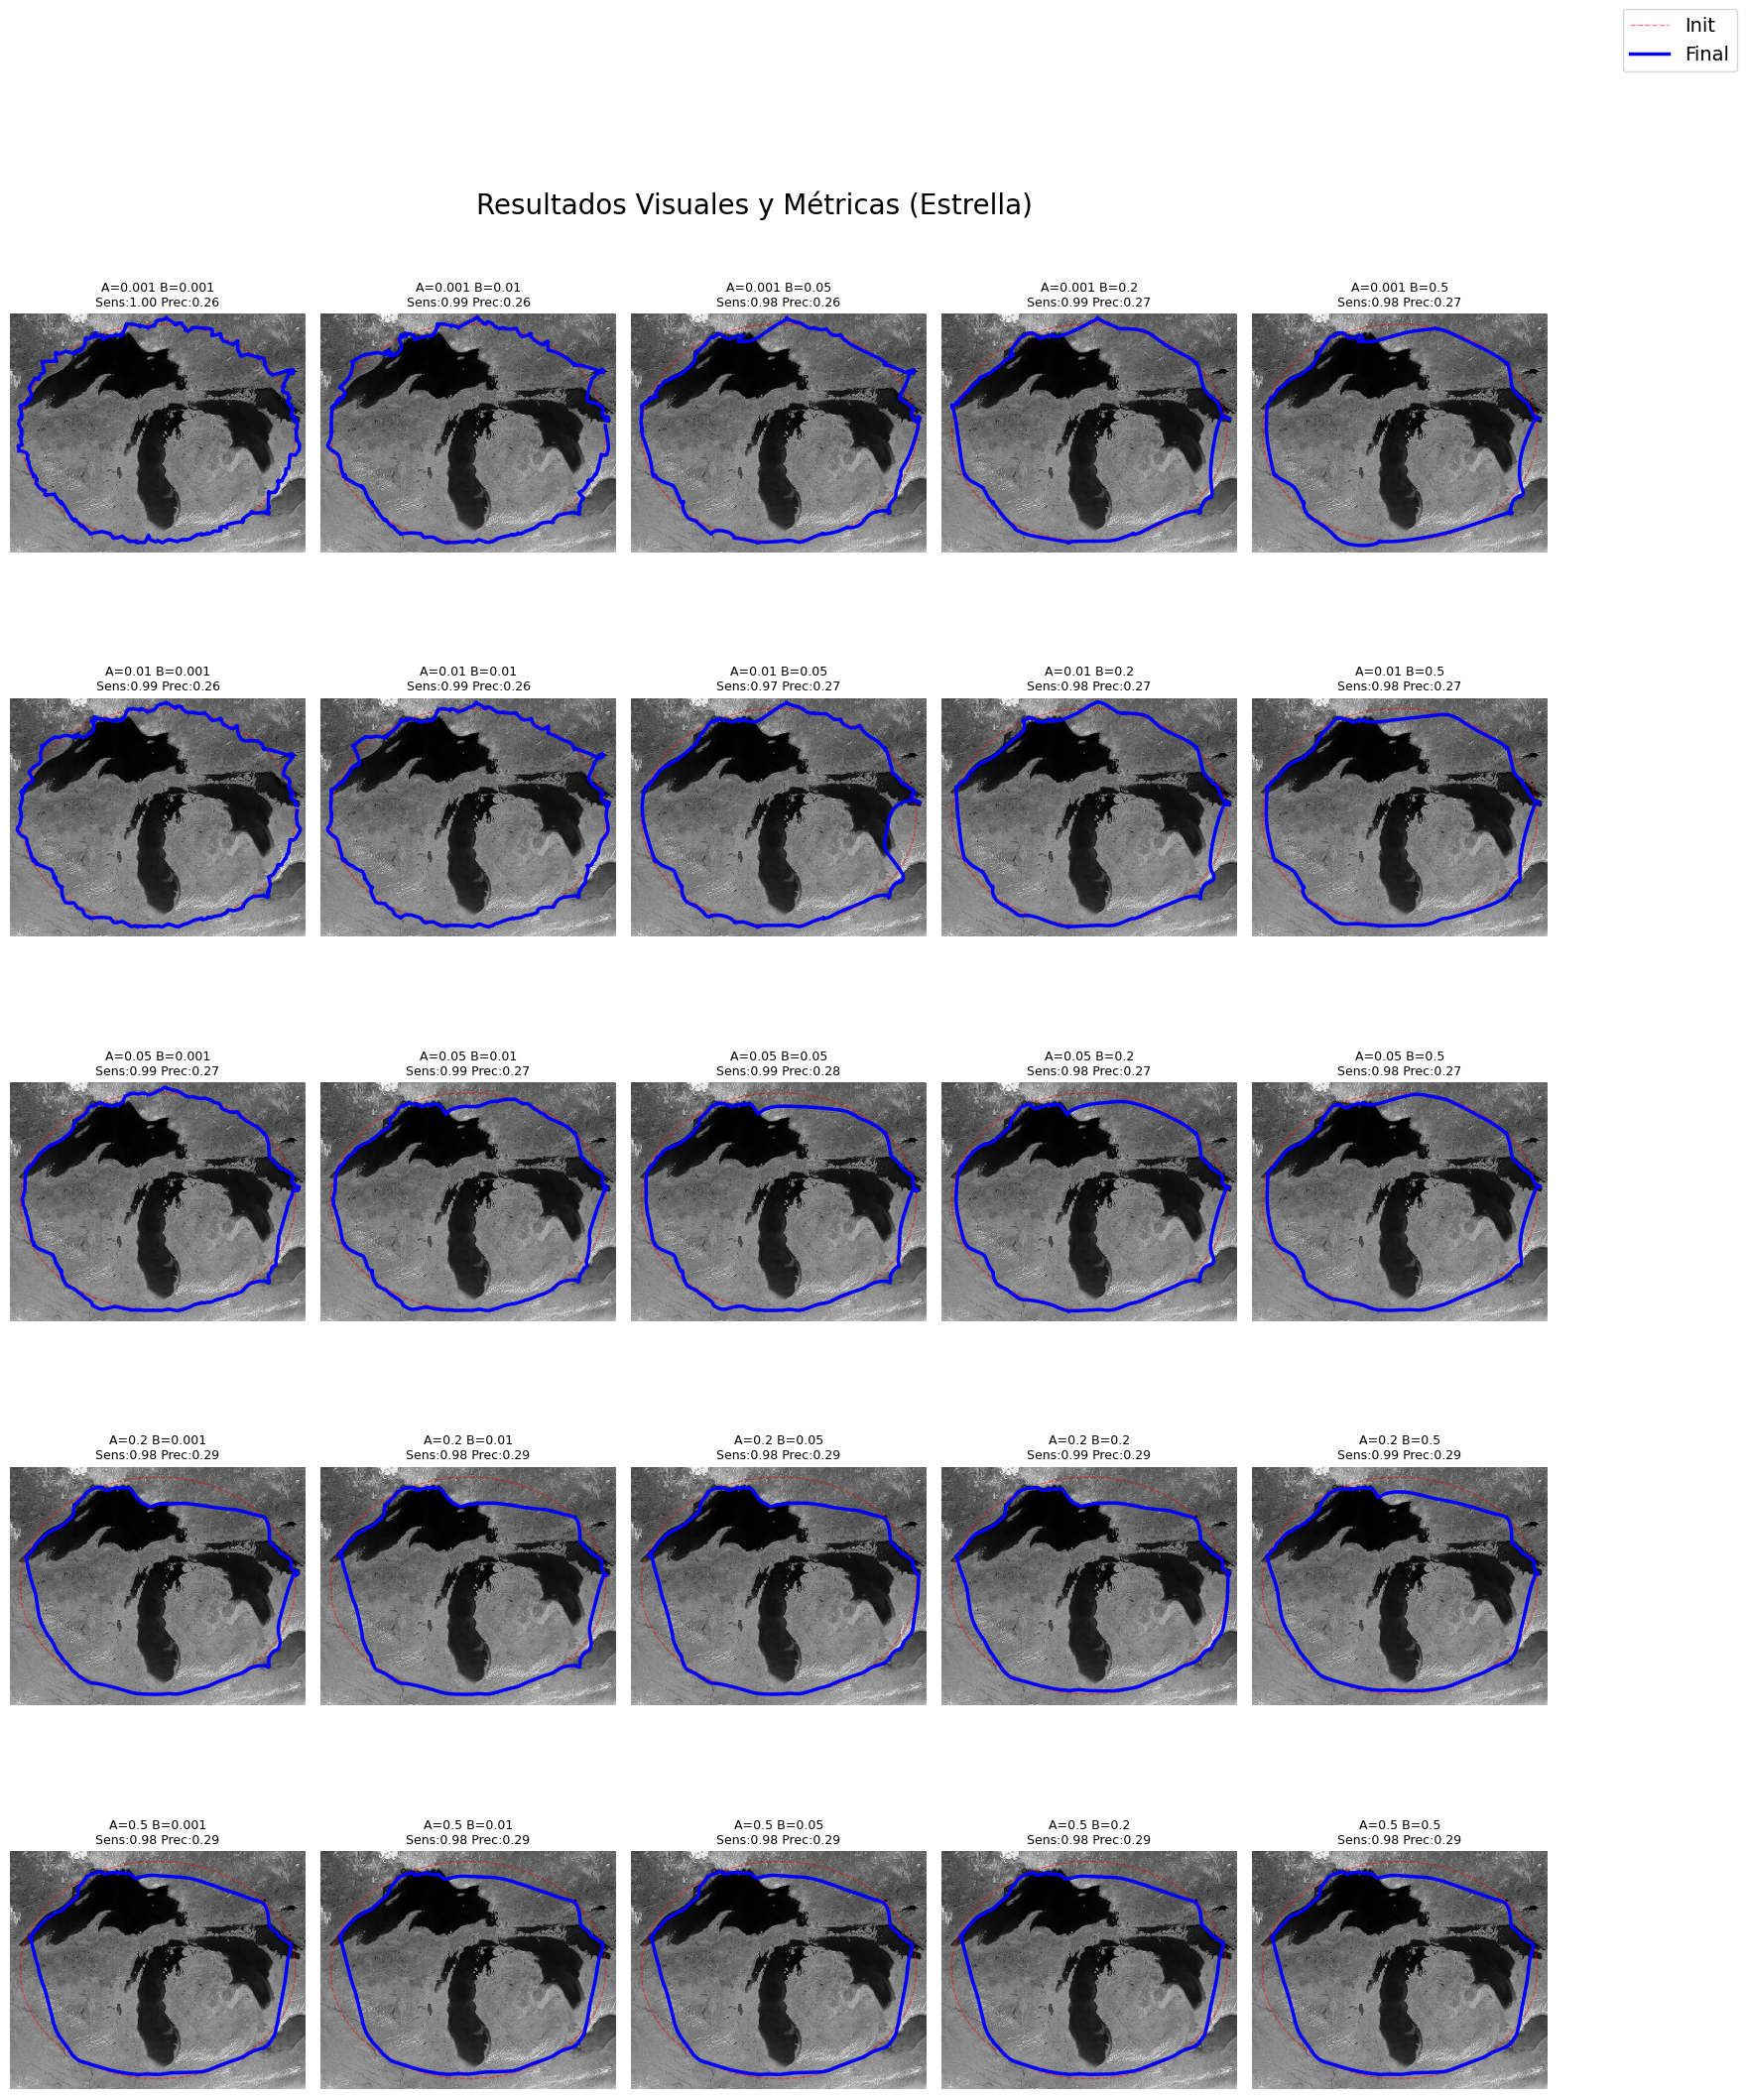


                  TABLA DE RESULTADOS NUMÉRICOS                  
  Alpha    |    Beta    |  Sensib.   |  Especif.  |  Precis.  
-----------------------------------------------------------------
  0.001    |   0.001    |   0.996    |   0.404    |   0.261   
  0.001    |   0.010    |   0.988    |   0.408    |   0.260   
  0.001    |   0.050    |   0.982    |   0.425    |   0.265   
  0.001    |   0.200    |   0.988    |   0.440    |   0.271   
  0.001    |   0.500    |   0.979    |   0.443    |   0.270   
  0.010    |   0.001    |   0.992    |   0.402    |   0.259   
  0.010    |   0.010    |   0.994    |   0.408    |   0.261   
  0.010    |   0.050    |   0.969    |   0.450    |   0.271   
  0.010    |   0.200    |   0.979    |   0.438    |   0.268   
  0.010    |   0.500    |   0.984    |   0.441    |   0.271   
  0.050    |   0.001    |   0.993    |   0.430    |   0.269   
  0.050    |   0.010    |   0.986    |   0.446    |   0.273   
  0.050    |   0.050    |   0.985    |   0.456  

In [ ]:
# Cargar imagen original
img_path = 'images/lakes3.jpg'
img = io.imread(img_path)
if len(img.shape) > 2: img = color.rgb2gray(img)
img = img_as_float(img)
img_smooth = gaussian(img, 1) # Suavizado ligero para el algoritmo
rows, cols = img.shape

# Cargar Ground Truth (La máscara ideal)
mask_star_gt = io.imread('images/Mascara_lagos.png', as_gray=True) > 0.5

# Inicialización del Snake (Círculo grande)
s = np.linspace(0, 2*np.pi, 600)
r = rows//2 + (rows//2 - 10)*np.sin(s)
c = cols//2 + (cols//2 - 10)*np.cos(s)
init = np.array([r, c]).T

# --- 3. CONFIGURACIÓN DE PARÁMETROS ---
alphas = [0.001, 0.01, 0.05, 0.2, 0.5] # Tensión
betas = [0.001, 0.01, 0.05, 0.2, 0.5]  # Rigidez

# Preparar figura y lista para guardar resultados
fig, axes = plt.subplots(5, 5, figsize=(20, 24), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.05, hspace=0.3)
metric_results = [] # Aquí guardaremos los datos para la tabla

print("Ejecutando análisis combinado (Visualización + Métricas)...")

# --- 4. BUCLE PRINCIPAL (GRID SEARCH) ---
for i, alpha in enumerate(alphas):
    for j, beta in enumerate(betas):
        ax = axes[i, j]
        
        # A. Ejecutar Active Contour (Parámetros del código visual)
        snake = active_contour(img_smooth, init, alpha=alpha, beta=beta, 
                               w_line=-2.0, w_edge=2.0, gamma=0.01, max_num_iter=2500)
        
        # B. Calcular Métricas
        mask_pred = snake_to_mask(snake, img.shape)
        sens, spec, prec = calculate_metrics(mask_star_gt, mask_pred)
        
        # Guardar dato para tabla final
        metric_results.append((alpha, beta, sens, spec, prec))
        
        # C. Visualización
        ax.imshow(img, cmap='gray')
        ax.plot(init[:, 1], init[:, 0], '--r', lw=1.0, alpha=0.5, label='Init')
        ax.plot(snake[:, 1], snake[:, 0], '-b', lw=2.5, label='Final')
        
        ax.set_xlim(0, cols)
        ax.set_ylim(rows, 0)
        
        # Título con métricas clave para referencia rápida visual
        ax.set_title(f"A={alpha} B={beta}\nSens:{sens:.2f} Prec:{prec:.2f}", fontsize=9)
        ax.axis('off')

# Añadir leyenda y título global
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=14)
plt.suptitle("Resultados Visuales y Métricas", y=0.92, fontsize=20)
plt.show()

# --- 5. IMPRIMIR TABLA DE RESULTADOS ---
print("\n" + "="*65)
print(f"{'TABLA DE RESULTADOS NUMÉRICOS':^65}")
print("="*65)
print(f"{'Alpha':^10} | {'Beta':^10} | {'Sensib.':^10} | {'Especif.':^10} | {'Precis.':^10}")
print("-" * 65)

for res in metric_results:
    print(f"{res[0]:^10.3f} | {res[1]:^10.3f} | {res[2]:^10.3f} | {res[3]:^10.3f} | {res[4]:^10.3f}")
print("="*65)

### Análisis de Resultados: Lagos

1.  **Adaptabilidad**:
    * Los resultados con **Beta bajo** suelen ser mejores aquí porque permiten que la línea azul siga la costa irregular del lago ("zig-zag").
    * Si usamos un **Beta alto**, obtendremos un lago "idealizado" (muy redondo), perdiendo las pequeñas bahías y penínsulas.

2.  **Fugas del contorno**:
    * Es posible que en algunas combinaciones la serpiente se "desborde" hacia zonas de tierra si el gradiente (la diferencia de color entre agua y tierra) no es muy fuerte en esa zona. Esto reduciría la **Precisión** (aumentan los Falsos Positivos).

Lo que vemos en las Métricas como en el caso de la estrella es que la sensibilidad es muy alta porque coge todo el objeto en la mayor parte de los casos pero la precisión y la especificidad nos dice en todos los casos que los resultados no son buenos, por tanto concluimos que el metodo en este caso falla.

## Caso de Estudio: Imagen Médica - Ecografía

Este es el caso más difícil y realista de la práctica.
* **Imagen**: `mama07ORI.bmp`.
* **Referencia**: `Mascara_ecografia.png`.

### El Reto: Ruido "Speckle" y Bordes Difusos
Las ecografías se caracterizan por tener mucho ruido (granulado) y bordes que no están definidos por una línea nítida, sino por cambios de textura.
* El gradiente en los bordes es muy débil.
* Hay mucho "ruido" dentro del objeto que puede confundir al algoritmo y hacer que la serpiente se detenga antes de llegar al borde real.

**Expectativa**:
Es probable que las métricas (Sensibilidad/Precisión) sean más bajas en general que en los ejemplos anteriores debido a la dificultad intrínseca de la imagen. Necesitaremos un equilibrio delicado en el suavizado.

Procesando Ecografía con inicialización centrada...


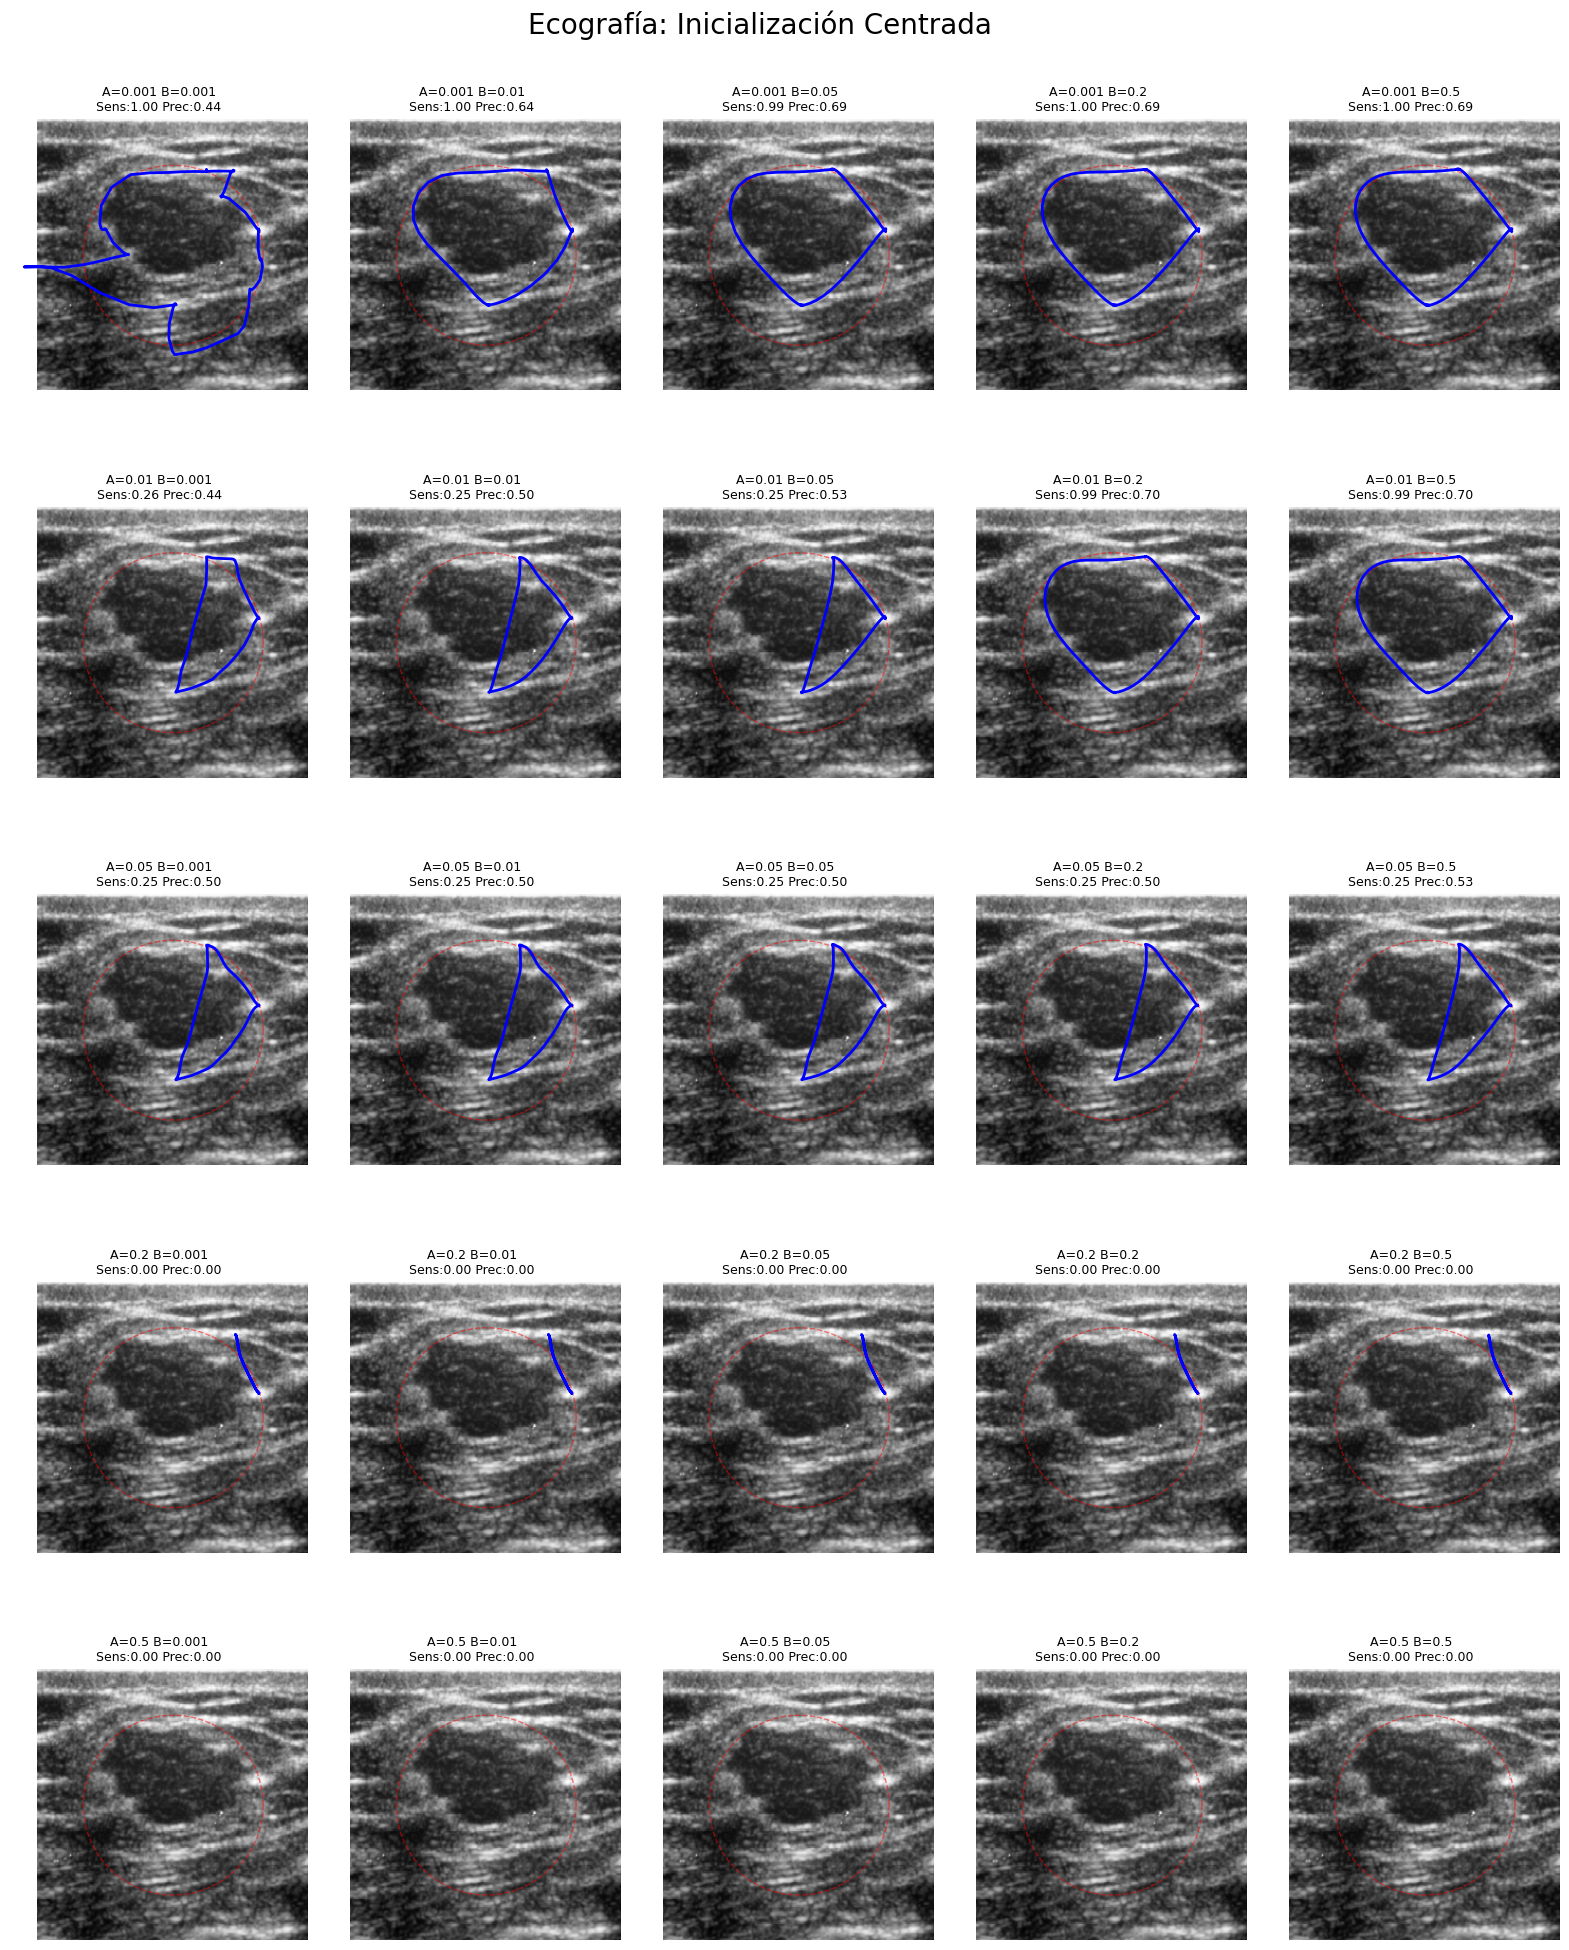

  Alpha    |    Beta    |  Sensib.   |  Especif.  |  Precis.  
-----------------------------------------------------------------
  0.001    |   0.001    |   0.999    |   0.802    |   0.435   
  0.001    |   0.010    |   1.000    |   0.915    |   0.644   
  0.001    |   0.050    |   0.994    |   0.933    |   0.694   
  0.001    |   0.200    |   0.996    |   0.932    |   0.693   
  0.001    |   0.500    |   0.996    |   0.933    |   0.694   
  0.010    |   0.001    |   0.264    |   0.949    |   0.441   
  0.010    |   0.010    |   0.255    |   0.961    |   0.501   
  0.010    |   0.050    |   0.251    |   0.965    |   0.526   
  0.010    |   0.200    |   0.991    |   0.935    |   0.700   
  0.010    |   0.500    |   0.993    |   0.934    |   0.697   
  0.050    |   0.001    |   0.252    |   0.961    |   0.495   
  0.050    |   0.010    |   0.252    |   0.961    |   0.497   
  0.050    |   0.050    |   0.251    |   0.961    |   0.496   
  0.050    |   0.200    |   0.251    |   0.962    | 

In [11]:
# --- CARGA ECOGRAFÍA ---
img_path = 'images/mama07ORI.bmp'
img = io.imread(img_path)
if len(img.shape) > 2: img = color.rgb2gray(img)
img = img_as_float(img)
# Mucho suavizado para ignorar el 'grano' del ultrasonido
img_smooth = gaussian(img, 4) 
rows, cols = img.shape

mask_gt = io.imread('images/Mascara_ecografia.png', as_gray=True) > 0.5

# --- CORRECCIÓN DE LA INICIALIZACIÓN ---
# Hacemos un círculo más pequeño (radio // 3) centrado
center_r, center_c = rows // 2, cols // 2
radius = min(rows, cols) // 3  # Radio más contenido para evitar bordes ruidosos

s = np.linspace(0, 2*np.pi, 400)
r = center_r + radius * np.sin(s)
c = center_c + radius * np.cos(s)
init = np.array([r, c]).T

# --- EJECUCIÓN ---
alphas = [0.001, 0.01, 0.05, 0.2, 0.5]
betas = [0.001, 0.01, 0.05, 0.2, 0.5]

fig, axes = plt.subplots(5, 5, figsize=(20, 24), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.05, hspace=0.3)
metric_results = []

print("Procesando Ecografía con inicialización centrada...")

for i, alpha in enumerate(alphas):
    for j, beta in enumerate(betas):
        ax = axes[i, j]
        
        # w_line=2.0 (Busca oscuro)
        snake = active_contour(img_smooth, init, alpha=alpha, beta=beta, 
                               w_line=2.0, w_edge=1.0, gamma=0.01, max_num_iter=2500)
        
        mask_pred = snake_to_mask(snake, img.shape)
        sens, spec, prec = calculate_metrics(mask_gt, mask_pred)
        metric_results.append((alpha, beta, sens, spec, prec))
        
        ax.imshow(img, cmap='gray')
        ax.plot(init[:, 1], init[:, 0], '--r', lw=1, alpha=0.5)
        ax.plot(snake[:, 1], snake[:, 0], '-b', lw=2)
        ax.set_title(f"A={alpha} B={beta}\nSens:{sens:.2f} Prec:{prec:.2f}", fontsize=9)
        ax.axis('off')

plt.suptitle("Ecografía: Inicialización Centrada", y=0.92, fontsize=20)
plt.show()

# --- TABLA ---
print(f"{'Alpha':^10} | {'Beta':^10} | {'Sensib.':^10} | {'Especif.':^10} | {'Precis.':^10}")
print("-" * 65)
for res in metric_results:
    print(f"{res[0]:^10.3f} | {res[1]:^10.3f} | {res[2]:^10.3f} | {res[3]:^10.3f} | {res[4]:^10.3f}")

### Análisis de Resultados: Ecografía

1.  **Sensibilidad al Ruido**:
    * Observaremos que si la serpiente no tiene suficiente tensión (Alpha muy bajo), puede quedarse atrapada en el "grano" de la ecografía dentro del objeto, resultando en una segmentación incompleta.

2.  **Importancia de la Forma (Beta)**:
    * Dado que las estructuras anatómicas suelen ser suaves u orgánicas, un **Beta moderado** puede ayudar a ignorar el ruido de borde y mantener una forma anatómica coherente, a diferencia del caso del lago donde queríamos mucho detalle.

3.  **Evaluación**:
    * Vemos que en este caso este método pese al ruido si que consigue resultados bastante aceptables en las tres métricas valoradas, con un alpha= 0.001 y un beta = 0.5 vemos unos resultados aceptables aunque no perfectos.

# 4 Conclusiones Generales de Active Contours

Tras analizar el comportamiento de los Contornos Activos (*Snakes*) en tres tipos de imágenes muy diferentes (geométrica, natural y médica), podemos extraer las siguientes conclusiones sobre los hiperparámetros:

### Sobre los Parámetros (Alpha y Beta)
1.  **Alpha ($\alpha$) - La Tensión**:
    * Determina cuánto se quiere encoger la serpiente.
    * **Alto**: Útil si el contorno inicial es mucho más grande que el objeto y necesitamos que se "apriete" rápido. Riesgo: puede colapsar o cortar partes del objeto.
    * **Bajo**: Necesario para objetos grandes o cuando la inicialización ya está cerca del borde.

2.  **Beta ($\beta$) - La Rigidez**:
    * Determina la suavidad de la curva.
    * **Alto**: Ideal para objetos redondos, suaves o artificiales (ej. monedas, células redondas).
    * **Bajo**: Imprescindible para objetos con esquinas, picos (estrella) o bordes rugosos (costa de un lago).

### Sobre la Inicialización y Preprocesamiento
* **Dependencia del Estado Inicial**: Los Snakes son muy sensibles a dónde colocamos el círculo inicial. Si lo ponemos demasiado lejos, pueden quedarse atrapados en "mínimos locales" (bordes falsos) antes de llegar al objeto.
* **Filtro Gaussiano**: Es el mejor aliado de los Snakes. Sin difuminar la imagen, el algoritmo es prácticamente inutilizable en imágenes reales debido al ruido.

### Resumen
No existe una combinación "perfecta" universal.
* Para la **Estrella**: Ganó la flexibilidad (Beta bajo).
* Para la **Ecografía**: Se necesitó robustez frente al ruido (balance entre Alpha/Beta y suavizado).
* El éxito de la segmentación depende de ajustar estos parámetros a la **naturaleza específica** de la imagen y la forma del objeto a detectar.

# 5Implementación de Snakes Morfológicos (MorphSnakes)

El siguiente código implementa el framework de **Snakes Morfológicos**, una aproximación eficiente y numéricamente estable a los modelos de contornos activos tradicionales. A diferencia de los métodos clásicos que resuelven Ecuaciones Diferenciales Parciales (EDP) complejas, este enfoque utiliza **operadores morfológicos** (dilatación y erosión sobre conjuntos de nivel binarios) para evolucionar la curva.

Esta implementación (adaptada del repositorio de `pmneila`) incluye dos arquitecturas fundamentales y un módulo de validación clínica:

### 1. Arquitecturas de Segmentación

#### A. `MorphACWE` (Active Contours Without Edges - Chan-Vese)
* **Tipo:** Modelo basado en **Regiones**.
* **Funcionamiento:** No depende de los gradientes (bordes) de la imagen. En su lugar, busca separar la imagen en dos regiones (dentro y fuera de la curva) minimizando la varianza de las intensidades en cada una.
* **Aplicación:** Ideal para imágenes con ruido (*speckle*), bordes difusos o texturas internas donde el gradiente no es fiable.

#### B. `MorphGAC` (Geodesic Active Contours)
* **Tipo:** Modelo basado en **Bordes**.
* **Funcionamiento:** Evoluciona la curva basándose en un mapa de atracción `g(I)` generado por la función `gborders` (magnitud del gradiente inverso).
* **Parámetros Clave:**
    * `balloon`: Fuerza de inflado (+1) o desinflado (-1) que empuja la curva hasta que choca con un borde fuerte.
    * `threshold`: Umbral para detener la evolución en el mapa de bordes.

### 2. Núcleo Matemático (`MorphologicalSnake`)
La clase base define el operador de curvatura `_curve_op`. Este método simula las fuerzas de tensión interna (suavizado) aplicando secuencialmente operadores morfológicos (`supin` y `infsup`) sobre la máscara binaria, eliminando rugosidades sin resolver derivadas numéricas.

### 3. Módulo de Evaluación y Visualización
Para validar objetivamente la calidad de la segmentación médica, se han integrado las siguientes herramientas:

* **Métricas Cuantitativas (`calculate_metrics`):** Compara la predicción con el *Ground Truth* pixel a pixel para calcular:
    * **Sensibilidad:** Capacidad de detectar la zona correcta del nódulo.
    * **Especificidad:** Capacidad de ignorar el tejido sano.
    * **Precisión:** Fiabilidad de la zona detectada.
* **Visualización Diagnóstica (`plot_full_analysis`):** Genera un panel de 4 vistas (Original, Contorno Superpuesto, Ground Truth y Máscara Final) para una inspección cualitativa inmediata.

In [ ]:
class MorphologicalSnake(object):
    """Clase base del repositorio pmneila/morphsnakes"""
    def __init__(self, data, smoothing=1, lambda1=1, lambda2=1):
        self.data = data
        self.smoothing = smoothing
        self.lambda1 = lambda1
        self.lambda2 = lambda2
        self._u = None # Level set

    def set_levelset(self, u):
        self._u = np.double(u)
        self._u[u > 0] = 1
        self._u[u <= 0] = 0

    def _curve_op(self, u):
        # Operador de curvatura (suavizado) usando SI y IS
        P2 = [np.eye(3), np.array([[0, 1, 0]] * 3), np.flipud(np.eye(3)), np.rot90([[0, 1, 0]] * 3)]
        
        def supin(u):
            return np.array([ndi.binary_erosion(u, structure=P) for P in P2], dtype=np.int8).max(0)
        
        def infsup(u):
            return np.array([ndi.binary_dilation(u, structure=P) for P in P2], dtype=np.int8).min(0)
            
        return supin(infsup(u)) # SI o IS

    def step(self):
        pass

class MorphACWE(MorphologicalSnake):
    """Active Contours Without Edges (Chan-Vese) - Repositorio pmneila"""
    def __init__(self, data, smoothing=1, lambda1=1, lambda2=1):
        super(MorphACWE, self).__init__(data, smoothing, lambda1, lambda2)

    def step(self):
        u = self._u
        data = self.data
        
        inside = u > 0
        outside = u <= 0
        
        c1 = data[inside].mean() if np.any(inside) else 0
        c0 = data[outside].mean() if np.any(outside) else 0

        # Fuerza de ajuste de imagen
        aux = (data - c1)**2 - (data - c0)**2 # Simplificado lambda=1
        
        res = np.copy(u)
        res[aux < 0] = 1
        res[aux > 0] = 0

        for _ in range(self.smoothing):
            res = self._curve_op(res)

        self._u = res

def gborders(img, alpha=1.0, sigma=1.0):
    """Función g(I) del repositorio para detectar bordes"""
    gradnorm = ndi.gaussian_gradient_magnitude(img, sigma, mode='nearest')
    return 1.0 / np.sqrt(1.0 + alpha * gradnorm)

class MorphGAC(MorphologicalSnake):
    """Geodesic Active Contours (GAC) - Repositorio pmneila"""
    def __init__(self, data, smoothing=1, threshold=0, balloon=0):
        super(MorphGAC, self).__init__(data, smoothing)
        self.balloon = balloon
        self.threshold = threshold

    def step(self):
        u = self._u
        gI = self.data
        res = np.copy(u)

        # 1. Balloon (Expansión/Contracción)
        if self.balloon > 0:
            aux = ndi.binary_dilation(u)
        elif self.balloon < 0:
            aux = ndi.binary_erosion(u)
        else:
            aux = u
            
        mask = gI > self.threshold
        res[mask] = aux[mask]

        # 2. Smoothing (Curvatura)
        for _ in range(self.smoothing):
            res = self._curve_op(res)
            
        self._u = res

# --- UTILIDADES DE INICIALIZACIÓN ---
def circle_level_set(shape, center, radius):
    r, c = np.mgrid[:shape[0], :shape[1]]
    dist = np.sqrt((r - center[0])**2 + (c - center[1])**2)
    return (dist <= radius).astype(float)

def checkerboard_level_set(shape, square_size=5):
    y, x = np.mgrid[:shape[0], :shape[1]]
    return ((x // square_size) + (y // square_size)) % 2

# --- VISUALIZACIÓN Y MÉTRICAS (Tu petición) ---
def calculate_metrics(ground_truth, prediction):
    gt = ground_truth.astype(bool).flatten()
    pred = prediction.astype(bool).flatten()
    tn, fp, fn, tp = confusion_matrix(gt, pred, labels=[False, True]).ravel()
    
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    return sens, spec, prec

def plot_full_analysis(original, gt, result, title):
    sens, spec, prec = calculate_metrics(gt, result)
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(title, fontsize=16)
    
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title("1. Original")
    
    axes[1].imshow(original, cmap='gray')
    axes[1].contour(result, [0.5], colors='r', linewidths=2)
    axes[1].set_title("2. Segmentación (Contorno)")
    
    axes[2].imshow(gt, cmap='gray')
    axes[2].set_title("3. Ground Truth")
    
    axes[3].imshow(result, cmap='gray')
    axes[3].set_title("4. Máscara Resultado")
    
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    print(f"--- RESULTADOS MATEMÁTICOS ({title}) ---")
    print(f"Sensibilidad: {sens:.4f}")
    print(f"Especificidad: {spec:.4f}")
    print(f"Precisión:     {prec:.4f}")
    print("-" * 40)

## Caso de Estudio: Segmentación de Topologías Complejas (Imagen Lagos)

En esta prueba abordamos un desafío distinto: la segmentación de objetos geográficos múltiples y desconectados (imagen Lagos) utilizando imágenes satelitales.

Para este escenario, cambiamos la estrategia con respecto al ejemplo anterior del nódulo:

1.  **Algoritmo: `MorphACWE` (Chan-Vese)**
    * **¿Por qué?** A diferencia de la ecografía, donde buscábamos un borde definido, aquí nos interesa separar **regiones estadísticas**. El agua presenta una intensidad media oscura y homogénea frente a la tierra (clara y texturizada). El modelo ACWE (Active Contours Without Edges) es ideal aquí porque minimiza la varianza dentro de las regiones en lugar de depender de gradientes de borde que pueden ser ruidosos en la costa.

2.  **Inicialización: `Checkerboard` (Tablero de Ajedrez)**
    * **¿Por qué?** Dado que los lagos son cuerpos separados y distribuidos por toda la imagen, iniciar con un solo círculo en el centro sería ineficiente (tardaría mucho en llegar a los bordes) o ineficaz (podría perderse los lagos lejanos).
    * Una inicialización tipo "tablero de ajedrez" siembra semillas de contorno por toda la imagen, permitiendo que el algoritmo capture múltiples objetos simultáneamente desde el principio.

**Nota Técnica:** El código incluye una validación final de **inversión**. Como ACWE separa dos regiones (A y B), a veces asigna el valor 1 al fondo y 0 al objeto. El script corrige esto automáticamente verificando la densidad media.

In [ ]:
# --- LAGOS ---
img = io.imread('images/lakes3.jpg')
gt = io.imread('images/Mascara_lagos.png', as_gray=True) > 0

# Preprocesamiento
if img.ndim == 3: img = color.rgb2gray(img)
img = img_as_float(img)

# Inicialización
init_ls = checkerboard_level_set(img.shape, square_size=10)

msnake = MorphACWE(img, smoothing=3, lambda1=1, lambda2=1)
msnake.set_levelset(init_ls)

# Iterar
for _ in range(200):
    msnake.step()

# Corrección de inversión (Chan-Vese a veces invierte fondo)
result = msnake._u
if result.mean() > 0.5: result = 1 - result

plot_full_analysis(img, gt, result, "Lagos (MorphACWE)")

### Análisis de Resultados: Flexibilidad Topológica

La ejecución del modelo `MorphACWE` sobre la imagen de los Lagos ilustra perfectamente la mayor ventaja de los métodos de **Level Set** frente a los snakes paramétricos tradicionales: la **adaptabilidad topológica**.

#### Observaciones Clave:

* **Manejo de Objetos Múltiples:**
    El algoritmo logró segmentar con éxito 5 grandes cuerpos de agua principales y varios cuerpos menores sin necesidad de indicar a priori cuántos objetos había. La curva inicial (el tablero de ajedrez) evolucionó, se fusionó y se separó automáticamete para rodear cada lago de forma individual.

* **Precisión Regional:**
    Comparando la *Segmentación (Imagen 2)* con el *Ground Truth (Imagen 3)*, vemos que el modelo captura fielmente la morfología compleja de las costas. La energía de región (Chan-Vese) demostró ser robusta:
    * Ignoró las variaciones de textura dentro de la tierra.
    * Capturó la homogeneidad del agua oscura.

* **Sensibilidad al Ruido (Pequeñas Islas):**
    Se observan pequeños puntos rojos (falsos positivos) en zonas de tierra (ver esquinas superiores). Esto ocurre porque esas pequeñas áreas tienen una intensidad media similar a la del agua. Esto se podría mitigar aumentando el parámetro `smoothing` (suavizado) o `lambda` (regularización), forzando al snake a ignorar regiones demasiado pequeñas.

**Conclusión del Experimento:**
Para imágenes donde el objetivo tiene un contraste claro de región (oscuro vs claro) y una topología compleja (múltiples objetos, formas irregulares), la combinación de **Chan-Vese (ACWE)** con inicialización global (**Checkerboard**) es superior a los métodos basados en bordes.

## Caso de Estudio: El Fotógrafo

En este experimento aplicamos el modelo **MorphACWE** (Chan-Vese) sobre la imagen de un fotógrafo.

A diferencia del caso de los lagos (objetos múltiples) o el nódulo (borde difuso), este escenario presenta un **sujeto único y central** pero con un desafío de **fondo mixto**:
1.  Un cielo plano y brillante (fácil de separar).
2.  Un suelo de césped texturizado y oscuro (difícil de separar del abrigo del fotógrafo).

**Estrategia de Inicialización:**
Se cambia el "Tablero de Ajedrez" por un **`circle_level_set`**.
* **Motivo:** Al saber que el objeto de interés es único y está centrado, iniciar con un círculo grande alrededor del sujeto actúa como un *prior* espacial. Esto ayuda al algoritmo a converger más rápido y reduce la probabilidad de capturar artefactos lejanos en el borde de la imagen desde el inicio.

In [ ]:
# --- FOTÓGRAFO ---
img = io.imread('images/camera.png')
gt = io.imread('images/Mascara_Fotografo.png', as_gray=True) > 0

if img.ndim == 3: img = color.rgb2gray(img)
img = img_as_float(img)

# Inicialización: Círculo en el centro del fotógrafo
init_ls = circle_level_set(img.shape, (200, 250), 100)

# MorphACWE
msnake = MorphACWE(img, smoothing=1, lambda1=1, lambda2=1)
msnake.set_levelset(init_ls)

for _ in range(150):
    msnake.step()

plot_full_analysis(img, gt, msnake._u, "Fotógrafo (MorphACWE)")

### Análisis de Resultados

Los resultados métricos y visuales exponen una limitación clásica de los modelos basados en regiones como Chan-Vese: la dependencia de la **estadística de intensidad**.

#### Interpretación de Métricas
* **Precisión (93.18%):**     Altamente fiable. De todo lo que el algoritmo marcó como "objeto", el 93% era correcto. Esto indica que el modelo no "alucinó" formas grandes fuera del sujeto.
* **Especificidad (97.48%):**
    Excelente. El modelo rechazó casi perfectamente el cielo, que constituye gran parte del fondo.
* **Sensibilidad (84.35%):**
    Moderada. Aunque capturó el abrigo, perdió ciertos detalles finos o áreas donde el contraste local era bajo (posiblemente partes del trípode o los pies).

#### Observaciones Visuales Críticas
Si observamos la imagen *2. Segmentación*, notamos "manchas rojas" en la parte inferior derecha (el césped).

1.  **El Problema del Césped:** El algoritmo asume que el objeto es "oscuro" y el fondo "claro". Sin embargo, el césped tiene una intensidad media similar a la del abrigo oscuro. El snake, al minimizar la varianza, se "confunde" e intenta incluir trozos de césped como parte del objeto.
2.  **Geometría Fina:** A pesar de ser un modelo de regiones, logró capturar las patas del trípode sorprendentemente bien, demostrando que la regularización ($\lambda$) estaba bien ajustada para permitir estructuras delgadas.

**Conclusión:**
El modelo es muy efectivo para separar el objeto del cielo, pero lucha en la zona inferior donde la **textura del fondo** rompe la hipótesis de homogeneidad de intensidad.

## Caso de Estudio: Monedas

En este experimento evaluamos el desempeño de **MorphACWE** en un escenario de conteo de objetos múltiples con una dificultad oculta: la iluminación no uniforme.

**Configuración del Experimento:**
1.  **Estrategia:** Seguimos utilizando el modelo basado en regiones (Chan-Vese) porque las monedas presentan una textura interna distinta al tapete de fondo.
2.  **Inicialización (`Checkerboard`):** Al igual que con los lagos, tenemos múltiples objetos distribuidos por todo el campo visual. Un "tablero de ajedrez" con cuadros pequeños (`square_size=15`) asegura que semillas del snake caigan tanto dentro como fuera de las monedas desde la iteración cero, acelerando la convergencia.

**El Reto Técnico:**
El modelo ACWE asume que la imagen se puede aproximar por dos constantes globales: el promedio de intensidad del objeto ($c_1$) y el promedio del fondo ($c_0$).
* *Hipótesis:* Si el fondo cambia de iluminación (gradiente de luz) y se vuelve tan brillante como las monedas en alguna zona, el modelo podría fallar teóricamente.

In [ ]:
# --- MONEDAS ---

img = io.imread('images/coins.png')
gt = io.imread('images/Mascara_monedas.png', as_gray=True) > 0

# Preprocesamiento
if img.ndim == 3: img = color.rgb2gray(img)
img = img_as_float(img)

# Inicialización: Tablero de Ajedrez (Checkerboard)
init_ls = checkerboard_level_set(img.shape, square_size=15)

# Configuración MorphACWE
# smoothing=1: Poco suavizado para que el contorno se pegue bien a la forma circular
msnake = MorphACWE(img, smoothing=1, lambda1=1, lambda2=1)
msnake.set_levelset(init_ls)

# Iteración
for _ in range(250):
    msnake.step()

result = msnake._u
if result.mean() > 0.5:
    result = 1 - result

plot_full_analysis(img, gt, result, "Monedas (MorphACWE Corregido)")

### Análisis de Resultados

Los resultados visuales y métricos confirman una limitación crítica del modelo Chan-Vese estándar: su **falta de robustez ante inhomogeneidades de intensidad (bias field)**.

#### Interpretación de los Fallos Visibles
Observando la imagen *2. Segmentación*, detectamos dos tipos de errores que explican las métricas (~83%):

1.  **Falso Positivo del Fondo (Esquina Superior Izquierda):**
    * **Causa:** La imagen original tiene una iluminación desigual; la esquina superior izquierda es mucho más brillante que la inferior derecha.
    * **Efecto:** Para el algoritmo, la intensidad de esa zona del "fondo" es estadísticamente más parecida al promedio de las "monedas" ($c_1$) que al promedio del fondo oscuro ($c_0$). Por tanto, la clasifica erróneamente como objeto. Esto penaliza la **Especificidad** y la **Precisión**.

2.  **Huecos dentro de las Monedas (Relieve):**
    * **Causa:** Las caras de las monedas tienen relieve y sombras.
    * **Efecto:** Las zonas oscuras dentro de la moneda (sombras del relieve) tienen una intensidad cercana al fondo. El snake crea "agujeros" internos, clasificando esas partes como fondo. Esto reduce la **Sensibilidad**.

**Conclusión:**
Aunque la inicialización de tablero funcionó para capturar la ubicación de todas las monedas, el modelo global **MorphACWE** es incapaz de distinguir el fondo brillante del objeto brillante. Para corregir esto, sería necesario un pre-procesamiento para corregir la iluminación o utilizar un modelo de **Active Contours Local** que analice estadísticas en vecindarios pequeños en lugar de toda la imagen.

## Caso de Estudio: Estrella de Mar

Este experimento enfrenta al modelo **MorphACWE** (Chan-Vese) a un desafío estructural: un objeto con **alta varianza interna** (textura rugosa con protuberancias y sombras) sobre un fondo uniforme.

**Estrategia de Configuración:**

1.  **El Problema de la Textura:**
    A diferencia de los lagos (agua plana), la estrella de mar tiene "ruido" estructural. Si el snake es demasiado flexible, intentará rodear cada pequeña protuberancia individualmente, generando miles de islas aisladas en lugar de un cuerpo único.

2.  **Ajuste Crítico: `smoothing=3`**
    Para mejorar la segmentacion aumentamos este parámetro para mejorar el suavizado.
    * **Objetivo:** Actuar como un filtro de rigidez fuerte. Esto fuerza al contorno a ignorar las pequeñas variaciones de alta frecuencia (los poros y granos de la piel de la estrella) y centrarse solo en la geometría general de los brazos.

3.  **Inicialización:**
    Se utiliza `circle_level_set` para encerrar la estrella y dejar que el snake se contraiga ("shrink-wrap") hasta encontrar el contorno exterior.

In [13]:
# --- ESTRELLA DE MAR ---
img = io.imread('images/seastar2.png')
gt = io.imread('images/Mascara_estrella.png', as_gray=True) > 0

if img.ndim == 3: img = color.rgb2gray(img)
img = img_as_float(img)

# Inicialización: Círculo grande
init_ls = circle_level_set(img.shape, (250, 250), 200)

# MorphACWE
msnake = MorphACWE(img, smoothing=3, lambda1=1, lambda2=1)
msnake.set_levelset(init_ls)

for _ in range(400):
    msnake.step()

# Corrección de inversión automática si captura el fondo
result = msnake._u
if result.mean() > 0.5: result = 1 - result

plot_full_analysis(img, gt, result, "Estrella (MorphACWE)")

NameError: name 'circle_level_set' is not defined

### Análisis de Resultados

Los resultados numéricos revelan un comportamiento fascinante típico de los modelos basados en regiones cuando se enfrentan a texturas fuertes sin un pre-procesamiento de suavizado de imagen agresivo.

#### Interpretación de las Métricas Extremas

* **Especificidad (99.94%) y Precisión (99.80%):**     Valores casi perfectos. Esto significa que el algoritmo **nunca se equivocó fuera de la estrella**. El fondo oscuro es tan homogéneo que el modelo no tuvo dudas: todo lo que marcó como "fondo" era realmente fondo.
* **Sensibilidad (70.80%):**
    Aquí radica el problema. A pesar de tener un contorno externo casi perfecto, el modelo "perdió" un 30% del área de la estrella.

#### Diagnóstico Visual: El Efecto "Queso Suizo"
Si miramos la *Imagen 4 (Máscara Resultado)*, vemos que el interior de la estrella está lleno de agujeros negros.

1.  **Causa:** La piel de la estrella tiene sombras profundas entre las espinas. Para el modelo matemático (que solo ve valores de gris), esas sombras tienen una intensidad casi idéntica a la del fondo del mar.
2.  **Fallo del Modelo:** Al intentar minimizar la varianza interna, el algoritmo decidió que era "más barato" energéticamente clasificar esas sombras internas como agujeros (fondo) que incluirlas como parte del objeto brillante.

**Conclusión:**
El parámetro `smoothing=3` fue exitoso para mantener la cohesión de los brazos (evitó que se separaran), pero no pudo evitar que la textura interna perforara la máscara. Para mejorar esto en una aplicación real, se requeriría un **filtro de relleno de agujeros** post-procesamiento.